In [1]:
url="https://raw.githubusercontent.com/royhridoy965-sketch/AI-and-ML-Lab/main/ANN/heart.csv"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [4]:
url="https://raw.githubusercontent.com/royhridoy965-sketch/AI-and-ML-Lab/main/ANN/heart.csv"

df=pd.read_csv(url)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [6]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [7]:
X=df.drop("target",axis=1)
y=df["target"]

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [10]:
X_train,X_val,y_train,y_val=train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [11]:
X_train=torch.FloatTensor(X_train)
X_val=torch.FloatTensor(X_val)
X_test=torch.FloatTensor(X_test)

y_train=torch.FloatTensor(y_train.values).reshape(-1,1)
y_val=torch.FloatTensor(y_val.values).reshape(-1,1)
y_test=torch.FloatTensor(y_test.values).reshape(-1,1)

In [12]:
batch_size=32

train_dataset=TensorDataset(X_train,y_train)
train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [13]:
class ShallowNN(nn.Module):
    def __init__(self,input_size):
        super().__init__()

        self.fc1=nn.Linear(input_size,32)
        self.relu=nn.ReLU()

        self.fc2=nn.Linear(32,1)

        self.sigmoid=nn.Sigmoid()

    def forward(self,x):

        x=self.relu(self.fc1(x))
        x=self.sigmoid(self.fc2(x))

        return x

In [14]:
class DeepNN(nn.Module):
    def __init__(self,input_size):
        super().__init__()

        self.net=nn.Sequential(

            nn.Linear(input_size,64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32,16),
            nn.ReLU(),

            nn.Linear(16,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [15]:
def train_model(
    model,
    optimizer,
    epochs=50
):

    criterion=nn.BCELoss()

    train_loss=[]
    val_loss=[]

    train_acc=[]
    val_acc=[]

    for epoch in range(epochs):

        model.train()

        running_loss=0

        correct=0
        total=0

        for X_batch,y_batch in train_loader:

            optimizer.zero_grad()

            outputs=model(X_batch)

            loss=criterion(outputs,y_batch)

            loss.backward()

            optimizer.step()

            running_loss+=loss.item()

            preds=(outputs>0.5).float()

            correct+=(preds==y_batch).sum().item()

            total+=y_batch.size(0)

        train_loss.append(running_loss/len(train_loader))
        train_acc.append(correct/total)

        model.eval()

        with torch.no_grad():

            val_outputs=model(X_val)

            loss=criterion(val_outputs,y_val)

            val_loss.append(loss.item())

            preds=(val_outputs>0.5).float()

            acc=(preds==y_val).float().mean()

            val_acc.append(acc.item())

    return train_loss,val_loss,train_acc,val_acc

In [16]:
shallow_model=ShallowNN(X_train.shape[1])

optimizer1=optim.Adam(
    shallow_model.parameters(),
    lr=0.001
)

shallow_history=train_model(
    shallow_model,
    optimizer1,
    epochs=50
)

In [17]:
deep_model=DeepNN(X_train.shape[1])

optimizer2=optim.Adam(
    deep_model.parameters(),
    lr=0.001,
    weight_decay=0.001
)

deep_history=train_model(
    deep_model,
    optimizer2,
    epochs=50
)

In [18]:
def evaluate(model):

    model.eval()

    with torch.no_grad():

        probs=model(X_test).numpy()

    preds=(probs>0.5).astype(int)

    acc=accuracy_score(y_test,preds)

    precision=precision_score(y_test,preds)

    recall=recall_score(y_test,preds)

    f1=f1_score(y_test,preds)

    fpr,tpr,_=roc_curve(y_test,probs)

    roc_auc=auc(fpr,tpr)

    return acc,precision,recall,f1,roc_auc,preds,probs,fpr,tpr

In [19]:
s_metrics=evaluate(shallow_model)
d_metrics=evaluate(deep_model)

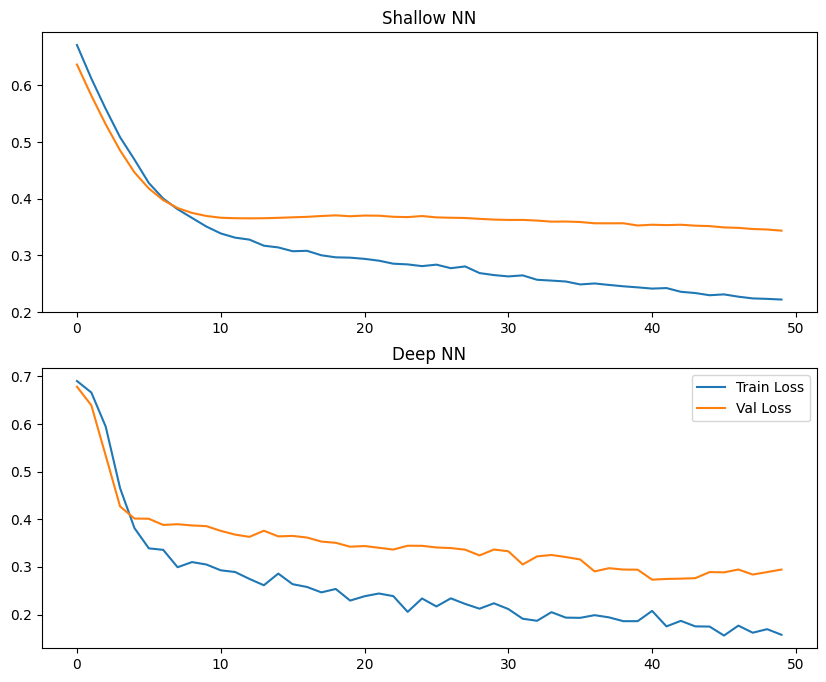

In [20]:
fig,ax=plt.subplots(2,1,figsize=(10,8))

ax[0].plot(shallow_history[0],label='Train Loss')
ax[0].plot(shallow_history[1],label='Val Loss')
ax[0].set_title("Shallow NN")

ax[1].plot(deep_history[0],label='Train Loss')
ax[1].plot(deep_history[1],label='Val Loss')
ax[1].set_title("Deep NN")

plt.legend()
plt.show()

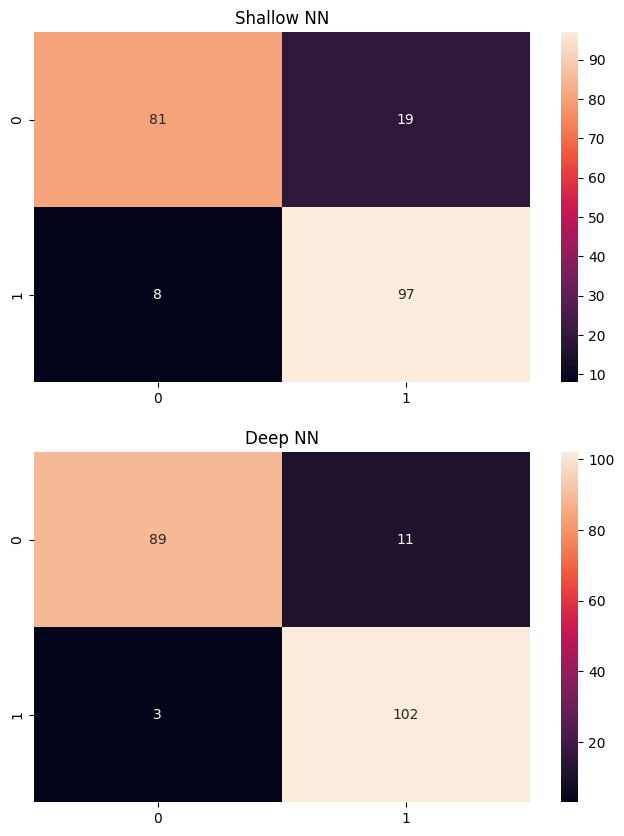

In [21]:
fig,ax=plt.subplots(2,1,figsize=(8,10))

sns.heatmap(
    confusion_matrix(y_test,s_metrics[5]),
    annot=True,
    fmt='d',
    ax=ax[0]
)

ax[0].set_title("Shallow NN")

sns.heatmap(
    confusion_matrix(y_test,d_metrics[5]),
    annot=True,
    fmt='d',
    ax=ax[1]
)

ax[1].set_title("Deep NN")

plt.show()

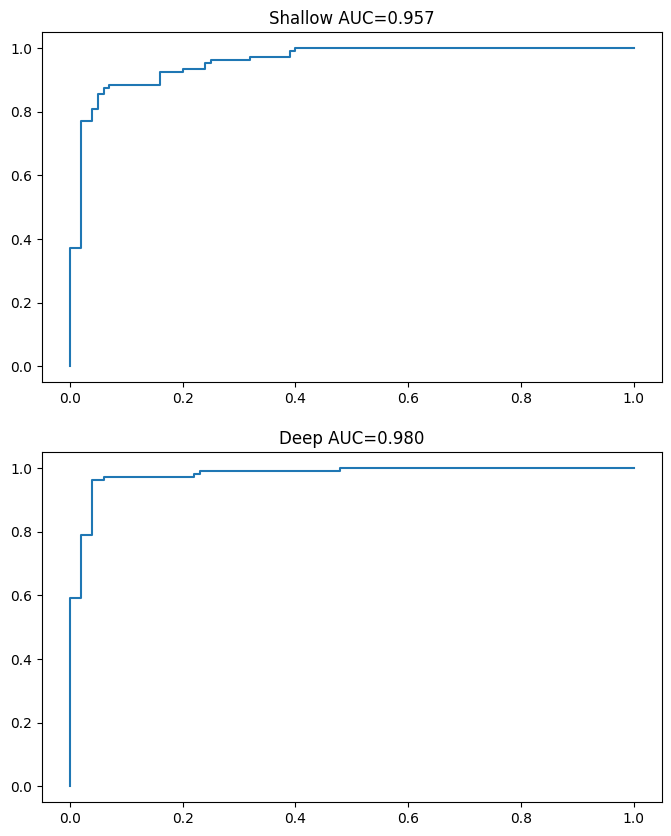

In [22]:
fig,ax=plt.subplots(2,1,figsize=(8,10))

ax[0].plot(
    s_metrics[7],
    s_metrics[8]
)

ax[0].set_title(
    f"Shallow AUC={s_metrics[4]:.3f}"
)

ax[1].plot(
    d_metrics[7],
    d_metrics[8]
)

ax[1].set_title(
    f"Deep AUC={d_metrics[4]:.3f}"
)

plt.show()

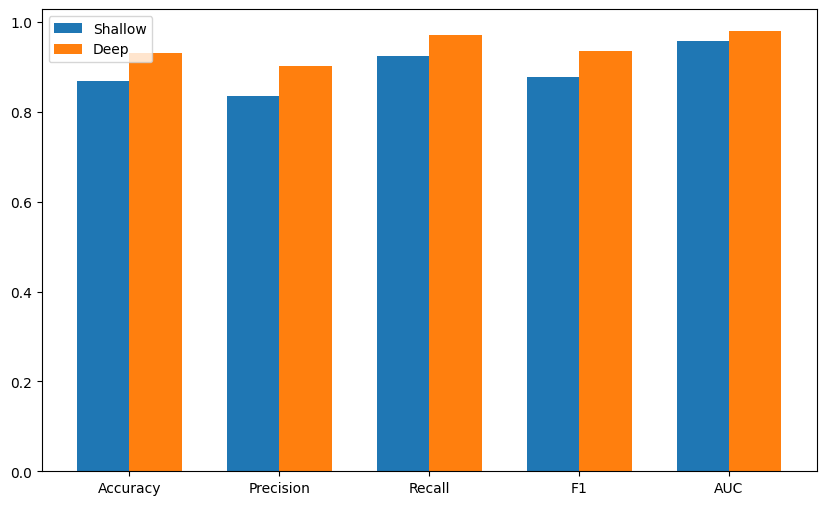

In [23]:
metrics=['Accuracy','Precision','Recall','F1','AUC']

shallow_values=list(s_metrics[:5])

deep_values=list(d_metrics[:5])

x=np.arange(len(metrics))

width=0.35

plt.figure(figsize=(10,6))

plt.bar(
    x-width/2,
    shallow_values,
    width,
    label='Shallow'
)

plt.bar(
    x+width/2,
    deep_values,
    width,
    label='Deep'
)

plt.xticks(x,metrics)

plt.legend()

plt.show()

In [24]:
print(shallow_model)

print("\n"*3)

print(deep_model)

ShallowNN(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)




DeepNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
